<a href="https://colab.research.google.com/github/banul25/shopper_spectrum/blob/main/shopper_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/Drive')

Mounted at /content/Drive


In [2]:
import os
os.listdir('/content/Drive/MyDrive')

['BANU_H_LAKSHMINARAYAN_Modern_Resume_10_10-1.pdf',
 'images-20260725T065642Z-1-001.zip',
 'Colab Notebooks',
 'face recognition.mp4',
 'online_retail.csv',
 'Group Project',
 'group project voyage analytics.mp4']

In [3]:
df= pd.read_csv("/content/Drive/MyDrive/online_retail.csv")


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Dataset Overview

Total records: 541,909 transactions

Total features: 8 columns

Dataset contains both numerical and categorical variables

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Missing Values

Description has 1,454 missing values (541,909 − 540,455).

CustomerID has 135,080 missing values (541,909 − 406,829), which is about 24.9% of the dataset.

Other columns have no missing values

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.duplicated().value_counts()

,count
False,536641
True,5268


In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [12]:
df[df['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2023-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2023-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2023-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2023-12-09 11:58:00,1.25,17315.0,United Kingdom


In [13]:
cancelled_rows = df['InvoiceNo'].str.startswith('C').sum()
print(cancelled_rows)

9288


In [14]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2023-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


**Invoice Information**

*There are 25,900 unique invoices.

*The most frequent invoice number is 573585, appearing 1,114 times.

*Presence of invoice numbers beginning with 'C' indicates cancelled transactions (should be removed for sales analysis).

**Product Information**

4,070 unique products (StockCode).

4,223 unique product descriptions.

Most purchased product:

*WHITE HANGING HEART T-LIGHT HOLDER

*Appears 2,369 times.

1. **Quantity Analysis**
*Average quantity purchased per transaction: 9.55 items

*Median quantity: 3 items

*Maximum quantity: 80,995 items

*Minimum quantity: -80,995 items

**Observation:**

*Negative quantities indicate returned or canceled orders.

*The large difference between mean (9.55) and median (3) suggests a right-skewed distribution with some bulk purchases.

**2. Unit Price Analysis**

*Average unit price: 4.61

*Median unit price: 2.08

*Maximum unit price: 38,970

*Minimum unit price: -11,062.06

**Observation:**

*Negative prices likely represent adjustments, refunds, or data-entry errors.

*Extremely high prices indicate outliers that should be investigated before modeling.

**3. Customer ID Analysis**

*Total records: 541,909

*Records with CustomerID: 406,829

**Observation:**

About 24.9% of transactions have missing Customer IDs, which may affect customer segmentation and RFM analysis.

**Country Analysis**

*Transactions come from 38 countries.

*Most transactions are from United Kingdom:

*495,478 transactions

*Approximately 91.4% of the dataset.

**Date Analysis**

*23,260 unique timestamps recorded.

8Most frequent transaction timestamp:

*2023-10-31 14:41:00

*Appears 1,114 times.

**4. Distribution Characteristics**

The mean is noticeably higher than the median for both Quantity and UnitPrice.
**Observation:**

*Quantity and UnitPrice have very large standard deviations compared to their means.

*This indicates high variability and presence of outliers.


data cleaning

In [15]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove returned transactions
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

print(df.shape)

(397884, 8)


The dataset contained 9,288 cancelled transaction records, identified by invoice numbers beginning with 'C'. These records were removed prior to analysis to ensure that sales, revenue, and customer behavior metrics reflected only completed purchases.

In [16]:
df = df[~df['InvoiceNo'].str.startswith('C')]
print(df.shape)

(397884, 8)


In [17]:
print(df['InvoiceNo'].str.startswith('C').sum())

0


In [18]:
cancelled_rows = df['InvoiceNo'].str.startswith('C').sum()
print(cancelled_rows)

0


EDA

analyze transcation volume by country

In [19]:
df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)

,InvoiceNo
Country,
United Kingdom,16646
Germany,457
France,389
EIRE,260
Belgium,98
Netherlands,94
Spain,90
Portugal,57
Australia,57


Transaction volume was analyzed using the number of unique invoices (InvoiceNo) per country. The United Kingdom recorded the highest transaction volume, indicating that it is the retailer's primary market. Other countries contributed a much smaller number of transactions, showing that sales are highly concentrated in the UK.

identifying top selling products

In [20]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


visualize purchase treands over time

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['Quantity'].sum()

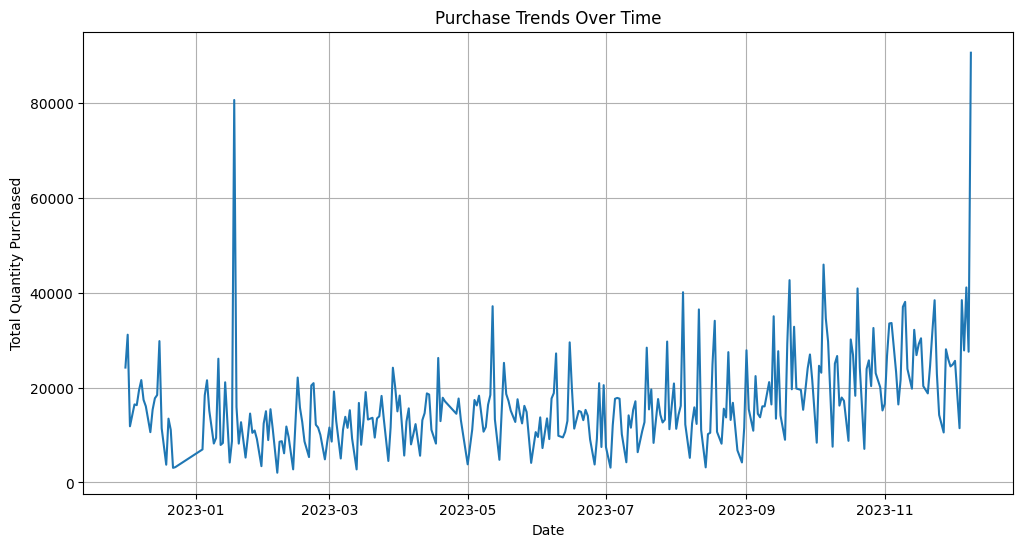

In [23]:
plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title('Purchase Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Total Quantity Purchased')
plt.grid(True)
plt.show()

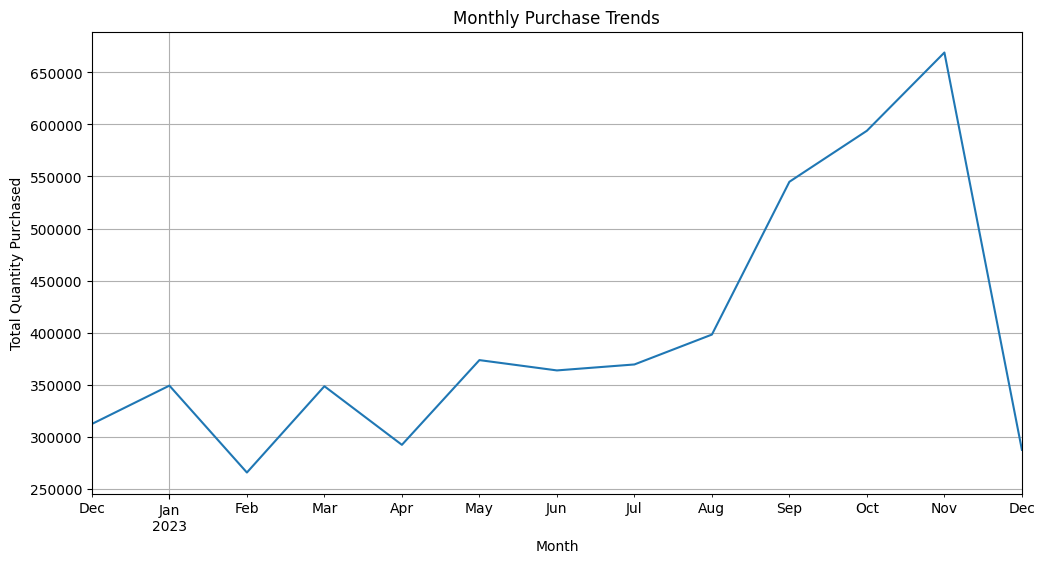

In [24]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Quantity'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()

plt.title('Monthly Purchase Trends')
plt.xlabel('Month')
plt.ylabel('Total Quantity Purchased')
plt.grid(True)
plt.show()

Purchase activity varies over time, with certain periods showing significantly higher sales volumes. The trend analysis helps identify seasonal patterns, peak shopping periods, and overall growth in customer purchases.

for preparing a retail analytics report, the monthly purchase trend is usually more informative than daily data because daily transactions can be noisy.

inspect monetary distribution per transaction and coustomer

In [25]:
df['monetary'] = df['Quantity'] * df['UnitPrice']
df['monetary']

,monetary
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
541904,10.20
541905,12.60
541906,16.60
541907,16.60


In [26]:
df['monetary'].describe()


,monetary
count,397884.000000
mean,22.397000
std,309.071041
min,0.001000
25%,4.680000
50%,11.800000
75%,19.800000
max,168469.600000


'monetary distribution per transcation

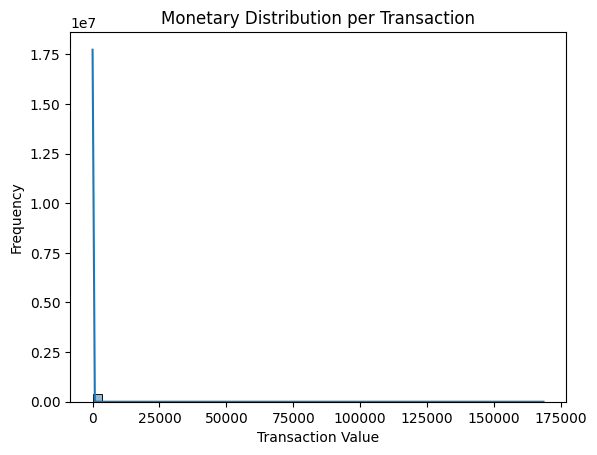

In [27]:
sns.histplot(df['monetary'], bins=50, kde=True)

plt.title('Monetary Distribution per Transaction')
plt.xlabel('Transaction Value')
plt.ylabel('Frequency')
plt.show()

monetary distribution per customer

In [28]:
customer_monetary = df. groupby('CustomerID')['monetary'].sum()
print(customer_monetary)

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: monetary, Length: 4338, dtype: float64


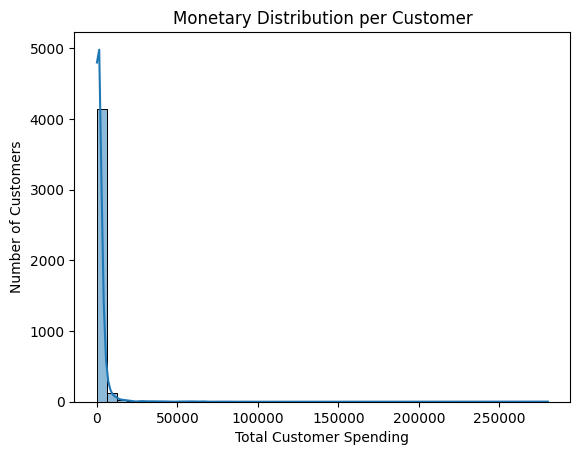

In [29]:
sns.histplot(customer_monetary, bins=45, kde=True)

plt.title('Monetary Distribution per Customer')
plt.xlabel('Total Customer Spending')
plt.ylabel('Number of Customers')
plt.show()

The monetary distribution was examined at both transaction and customer levels. The distributions are expected to be right-skewed, with most transactions and customers having relatively lower monetary values and a smaller number contributing higher-value purchases.

RFM distribution


choosing the reference date

In [30]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

calculaterecency

In [31]:
recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency.head()

,InvoiceDate
CustomerID,
12346.0,2023-01-18 10:01:00
12347.0,2023-12-07 15:52:00
12348.0,2023-09-25 13:13:00
12349.0,2023-11-21 09:51:00
12350.0,2023-02-02 16:01:00


calaulate the number of days b/w the reference date and last purchase

In [32]:
recency = ((snapshot_date - recency).dt.total_seconds() / (24 * 3600)).astype(int)
recency.head()

,InvoiceDate
CustomerID,
12346.0,326
12347.0,2
12348.0,75
12349.0,19
12350.0,310


calculate frequency

In [33]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
frequency.head()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1


combineing all recency,frequency and coustomer monetary

In [34]:
rfm = pd.DataFrame({'Recency' : recency,
                   'Frequency' : frequency,
                   'Monetary': customer_monetary
                   })

In [35]:
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**Lower Recency** = purchased more recently

**Higher Frequency** = purchased more often

**Higher Monetary** = spent more

In [36]:
rfm.shape

(4338, 3)

In [37]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


plot re

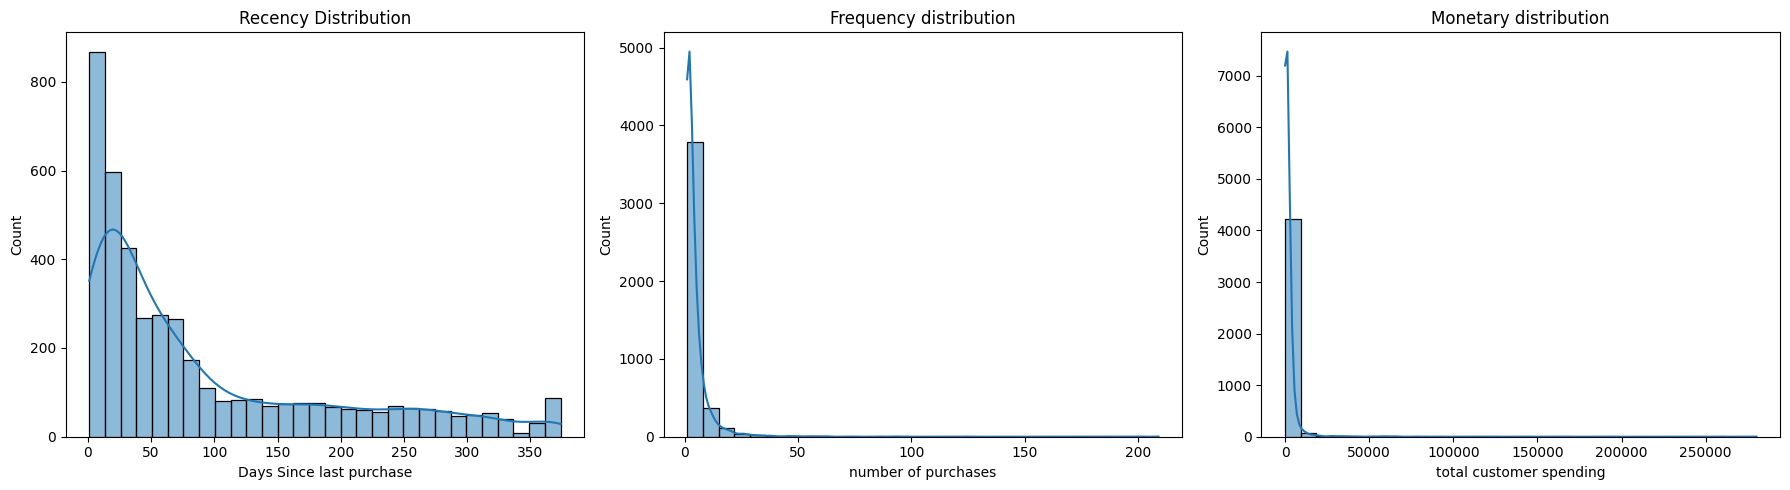

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since last purchase')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency distribution')
axes[1].set_xlabel('number of purchases')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary distribution')
axes[2].set_xlabel('total customer spending')

plt.tight_layout()
plt.show()

Standardize RFM values

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
# Convert back to DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


Positive value → above the average
Negative value → below the average
Around 0 → close to the average

For example, customer 12346 has:

Recency = 2.33 → much higher than average Recency
Frequency = -0.43 → below-average Frequency
Monetary = 8.36 → extremely high Monetary value

we selected K-Means Clustering for customer segmentation.

Why K-Means?

We are working with numerical RFM features: Recency, Frequency, and Monetary.

K-Means groups customers based on similarity in these features.

It is simple and easy to interpret.

The Elbow Method can be used directly with K-Means to determine the appropriate number of clusters.

The resulting clusters can be easily analyzed using their average RFM values.

**Elbow Method**

In [40]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

kmeans.inertia gives WCSS for that particular k

plot the elbow curve

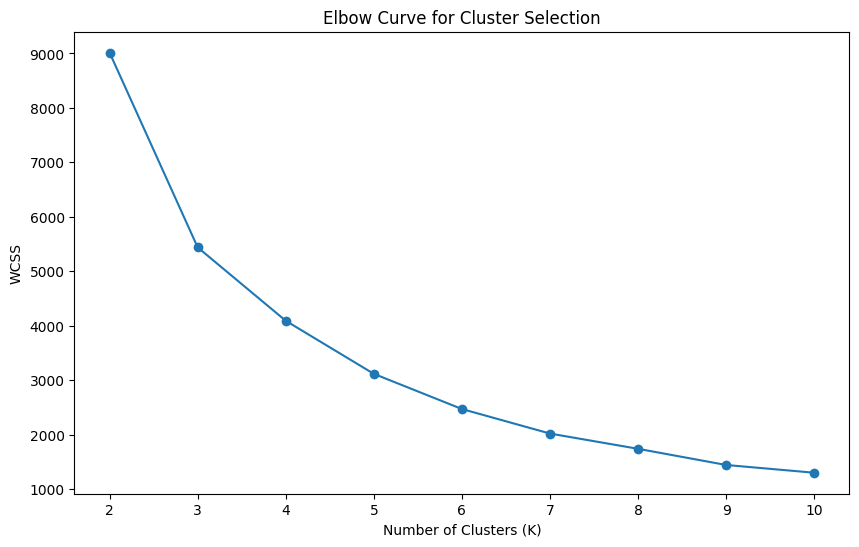

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), wcss, marker='o')

plt.title('Elbow Curve for Cluster Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

The elbow curve was used to determine the appropriate number of customer clusters. WCSS decreases significantly as the number of clusters increases from 2 to 4. After K=4, the reduction in WCSS becomes more gradual. Therefore, K=4 was selected as a candidate number of clusters for RFM-based customer segmentation.

**Customer cluster profiles**

In [42]:
from sklearn.cluster import KMeans

# Create 4 clusters
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster_4'] = kmeans_4.fit_predict(rfm_scaled)

to check number of customer in each cluster

In [43]:
rfm['Cluster_4'].value_counts().sort_index()

,count
Cluster_4,
0,3054
1,1067
2,13
3,204


**Cluster 0:** largest group — about 70% of customers

**Cluster 1:** second-largest group — about 25%

**Cluster 2:** only 13 customers, which is extremely small


**Cluster 3:** smaller group — about 5%




**Calculate the average RFM values for K=4**

In [44]:
cluster_4_summary = rfm.groupby('Cluster_4')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_4_summary

,Recency,Frequency,Monetary
Cluster_4,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


**Lower Recency** = purchased more recently

**Higher Frequency** = purchased more often

**Higher Monetary** = spent more

**Cluster 0** — 3,054 customers

**Recency:**   43.7 days

**Frequency:** 3.68 purchases

**Monetary:**  1,359

These customers have moderate recency, relatively low purchase frequency, and moderate spending.

This is your main customer group, containing about 70% of customers.

**Cluster 1** — 1,067 customers

**Recency:**   248 days

**Frequency:** 1.55 purchases

**Monetary:**  481

These customers:

haven't purchased recently
purchase relatively infrequently
spend relatively little

So this is a group with low recent activity.

**Cluster 2** — 13 customers

**Recency:**   7.4 days

**Frequency:** 82.5 purchases

**Monetary:**  127,338

This is a very small group of 13 customers, but their RFM values are dramatically higher:

very recent purchases
extremely high purchase frequency
extremely high spending

This explains why K-Means created a separate cluster for them.

Because there are only 13 customers, you should also check these customers individually to make sure they aren't unusual/outlier cases.

**Cluster 3** — 204 customers

**Recency:**   15.5 days

**Frequency:** 22.3 purchases

**Monetary:**  12,709

These customers also have:

recent purchases
high purchase frequency
high spending

**report**

The K=4 clustering identified four distinct customer groups based on RFM characteristics.

**Cluster 0** represented the majority of customers with moderate recency, frequency, and monetary value.

 **Cluster 1** consisted of customers with higher recency and lower frequency and spending.

  **Cluster 3** contained relatively recent, frequent, and higher-spending customers.

  **Cluster 2** was a very small group of 13 customers with exceptionally high frequency and monetary values.

**Silhouette Score**

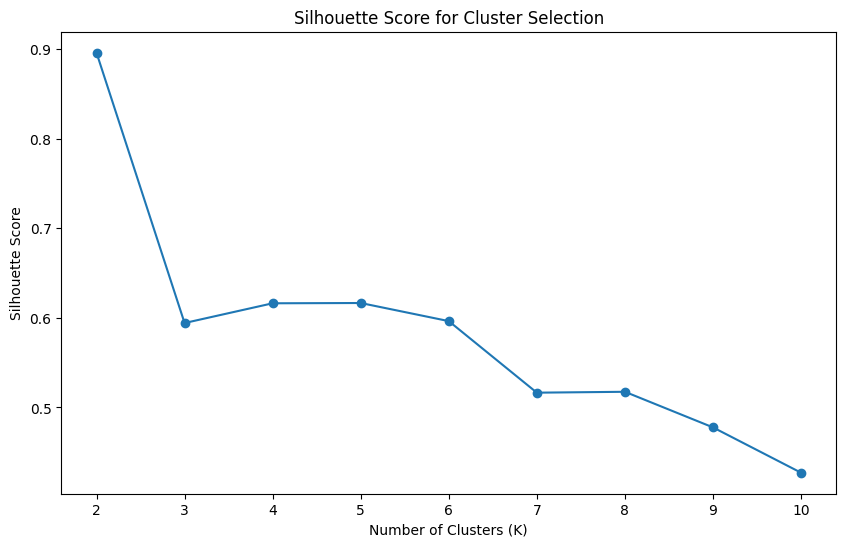

In [45]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.title('Silhouette Score for Cluster Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

according to the Silhouette Score, K = 2 has the strongest separation among the K values you tested.

In [46]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)

rfm['Cluster_2'] = kmeans_2.fit_predict(rfm_scaled)

In [47]:
rfm['Cluster_2'].value_counts().sort_index()

,count
Cluster_2,
0,4312
1,26


**Calculate the average RFM values for K=2**

In [48]:
cluster_2_summary = rfm.groupby('Cluster_2')[['Recency',
                                               'Frequency',
                                               'Monetary']].mean()

cluster_2_summary

,Recency,Frequency,Monetary
Cluster_2,,,
0,93.057978,3.897263,1548.676893
1,6.038462,66.423077,85904.351538


**Compare K=2 and K=4 **

In [49]:
print("K = 2")
display(cluster_2_summary)

print("K = 4")
display(cluster_4_summary)

K = 2


,Recency,Frequency,Monetary
Cluster_2,,,
0,93.057978,3.897263,1548.676893
1,6.038462,66.423077,85904.351538


K = 4


,Recency,Frequency,Monetary
Cluster_4,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


**Compare cluster sizes visually**

**K=2**

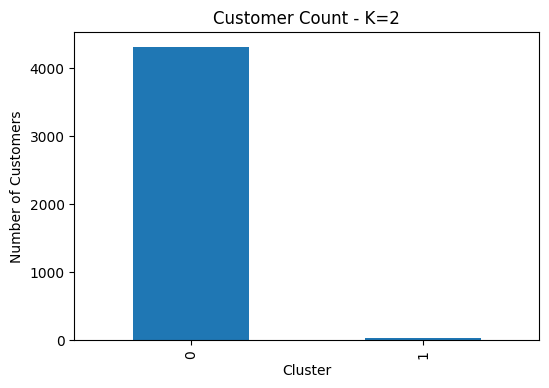

In [50]:
plt.figure(figsize=(6, 4))

rfm['Cluster_2'].value_counts().sort_index().plot(kind='bar')

plt.title('Customer Count - K=2')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

# **K=4**

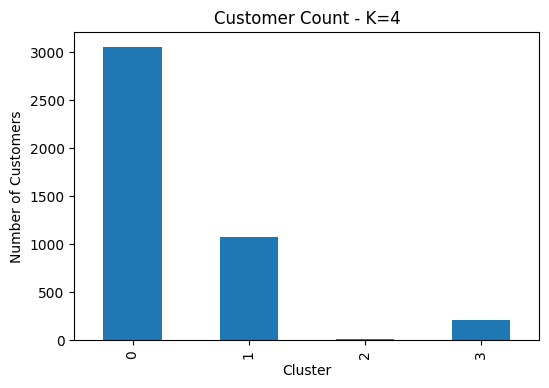

In [51]:
plt.figure(figsize=(6, 4))

rfm['Cluster_4'].value_counts().sort_index().plot(kind='bar')

plt.title('Customer Count - K=4')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

Both the Elbow Method and Silhouette Score were evaluated to determine the appropriate number of clusters. The Elbow Method indicated K=4, while the Silhouette Score produced its highest value at K=2. Considering the objective of obtaining more detailed RFM-based customer segments, K=4 was selected for the final clustering analysis

2D Scatter Plots (RFM Pairwise Comparisons)

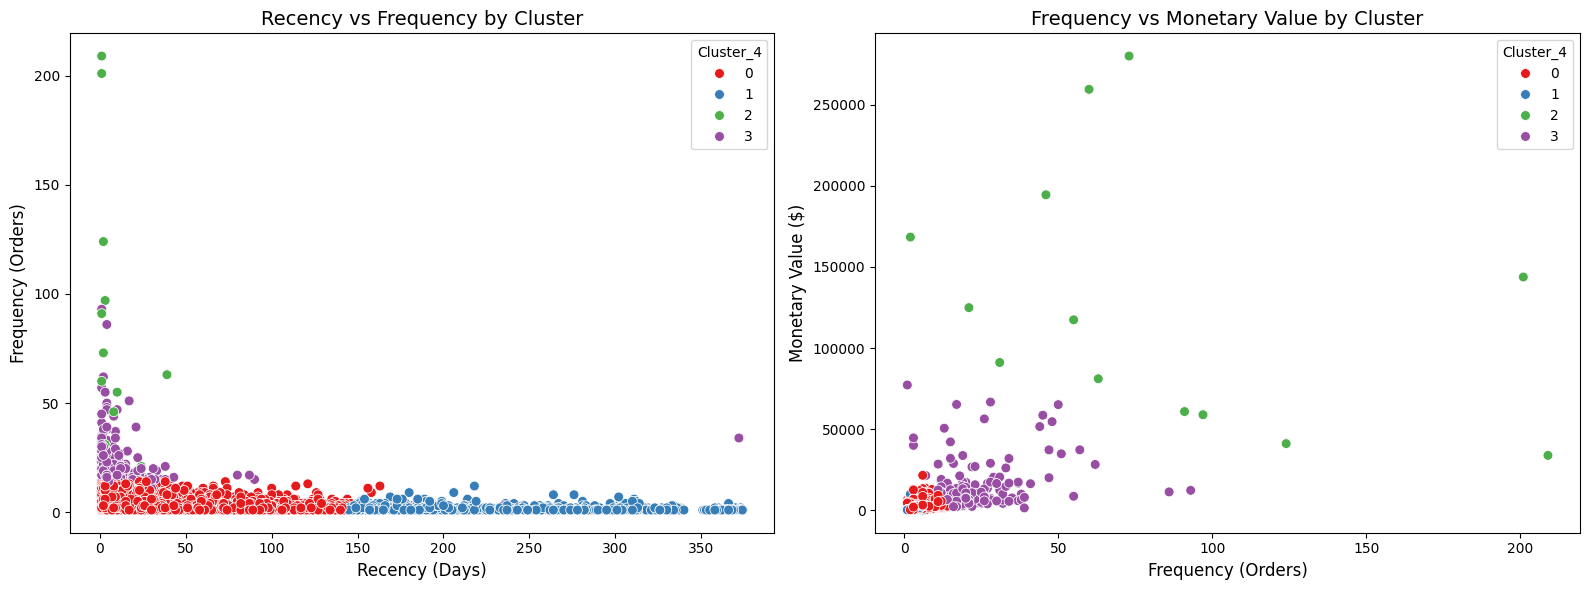

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recency vs Frequency
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster_4',
    palette='Set1',
    ax=axes[0],
    s=50
)
axes[0].set_title('Recency vs Frequency by Cluster', fontsize=14)
axes[0].set_xlabel('Recency (Days)', fontsize=12)
axes[0].set_ylabel('Frequency (Orders)', fontsize=12)

# Plot 2: Frequency vs Monetary
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster_4',
    palette='Set1',
    ax=axes[1],
    s=50
)
axes[1].set_title('Frequency vs Monetary Value by Cluster', fontsize=14)
axes[1].set_xlabel('Frequency (Orders)', fontsize=12)
axes[1].set_ylabel('Monetary Value ($)', fontsize=12)

plt.tight_layout()
plt.show()

3D Scatter Plot (All 3 RFM Dimensions Together)

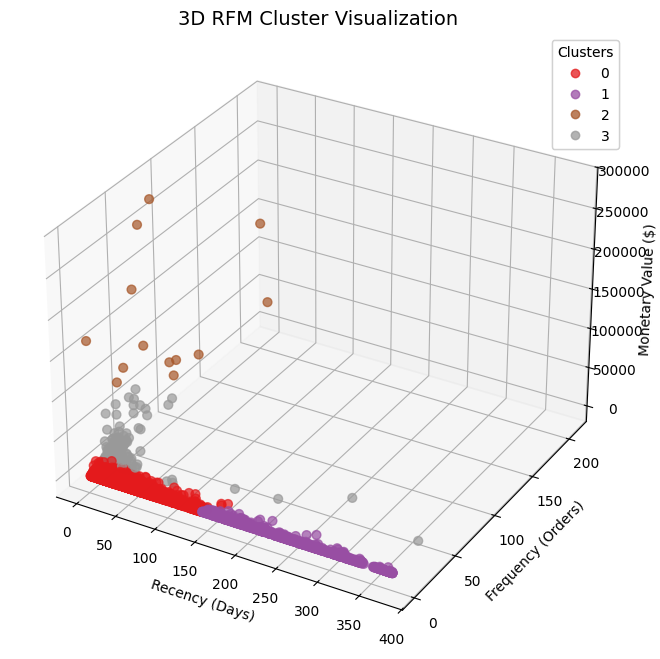

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using scaled or unscaled RFM data
scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster_4'],
    cmap='Set1',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Orders)')
ax.set_zlabel('Monetary Value ($)')
ax.set_title('3D RFM Cluster Visualization', fontsize=14)

# Add legend
legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
ax.add_artist(legend)

plt.show()

In [54]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# 1. Create Customer-Product Interaction Matrix (1 if bought, 0 if not)
user_item_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum'
).fillna(0)

# Convert to binary matrix (or keep raw quantities if preferred)
user_item_matrix_binary = (user_item_matrix > 0).astype(int)

# 2. Compute Cosine Similarity between Products (Columns)
item_similarity = cosine_similarity(user_item_matrix_binary.T)

# Convert to DataFrame with product descriptions as index and columns
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# 3. Recommendation Function
def get_top_5_recommendations(product_name, similarity_df):
    if product_name not in similarity_df.index:
        return f"Product '{product_name}' not found in catalog."

    # Get similarity scores for the product and sort descending
    sim_scores = similarity_df[product_name].sort_values(ascending=False)

    # Exclude the item itself (top score = 1.0) and pick top 5
    top_5 = sim_scores.iloc[1:6]
    return top_5

# Example Usage Test:
sample_product = user_item_matrix.columns[0]
print(f"Top 5 products similar to '{sample_product}':")
print(get_top_5_recommendations(sample_product, item_similarity_df))

Top 5 products similar to ' 4 PURPLE FLOCK DINNER CANDLES':
Description
4 PINK DINNER CANDLE SILVER FLOCK      0.598799
4 BLUE DINNER CANDLES SILVER FLOCK     0.441771
4 IVORY DINNER CANDLES SILVER FLOCK    0.342148
4 PINK FLOCK CHRISTMAS BALLS           0.254000
HEN HOUSE W CHICK IN NEST              0.179605
Name:  4 PURPLE FLOCK DINNER CANDLES, dtype: float64


save thebest model

In [57]:
import joblib
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files

# 1. Build Item-based Recommendation Similarity Matrix
user_item_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum'
).fillna(0)

user_item_matrix_binary = (user_item_matrix > 0).astype(int)
item_similarity = cosine_similarity(user_item_matrix_binary.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# 2. Package RFM + Recommendation artifacts into 'rfm_model.pkl'
model_payload = {
    'model': kmeans_4,
    'scaler': scaler,
    'features': ['Recency', 'Frequency', 'Monetary'],
    'cluster_labels': {
        0: 'Regular / Moderate Spend',
        1: 'At-Risk / Inactive',
        2: 'VIP / High Value',
        3: 'Loyal / High Spend'
    },
    'item_similarity_df': item_similarity_df,
    'product_list': list(item_similarity_df.index)
}

# 3. Save and Download
joblib.dump(model_payload, 'rfm_model1.pkl')
print("rfm_model.pkl updated successfully!")

files.download('rfm_model1.pkl')

rfm_model.pkl updated successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>